# Hourly LSTM training 

Trains **Single / Double / BiLSTM** on clean preprocessed data .


In [21]:
window_sizes = [1, 4, 8, 12, 16, 24, 36, 48, 74, 168, 336, 672]
epochs = 50
batch_size = 32
test_ratio = 0.18


from google.colab import drive
drive.mount("/content/drive")
BASE = "/content/drive/MyDrive/Shared-Colab-Storage/research"

DATA_CSV = f"{BASE}/outputs/preprocess/hourly/data.csv"
SCALER_PKL = f"{BASE}/outputs/preprocess/hourly/scaler.pkl"
SAVE_PATH = f"{BASE}/outputs/train/hourly"
TUNING_JSON = f"{BASE}/outputs/train/hourly/tuning/best_hparams.json"

print("DATA:", DATA_CSV)
print("SAVE:", SAVE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA: /content/drive/MyDrive/Shared-Colab-Storage/research/outputs/preprocess/hourly/data.csv
SAVE: /content/drive/MyDrive/Shared-Colab-Storage/research/outputs/train/hourly


In [14]:
!pip install -q pandas numpy scikit-learn matplotlib tensorflow

import os
import pickle
import json

import matplotlib.pyplot as plt
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend as K
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

def rmse(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_true - y_pred)))

os.makedirs(SAVE_PATH, exist_ok=True)

## Load preprocessed hourly data

In [3]:
scaled_df = pd.read_csv(DATA_CSV)
with open(SCALER_PKL, "rb") as f:
    scaler = pickle.load(f)

feature_cols = list(scaled_df.columns)
target_idx = 0  
n_features = len(feature_cols)

print("Rows:", len(scaled_df))
print("Features (9 after preprocess):", feature_cols)
scaled_df.head()

Rows: 8760
Features (9 after preprocess): ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'WeekStatus', 'Day_of_week', 'Load_Type', 'hour_sin', 'hour_cos']


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,WeekStatus,Day_of_week,Load_Type,hour_sin,hour_cos
0,0.007306,0.049021,0.497919,1.0,0.0,0.166667,0.0,0.549246,1.000000
1,0.007638,0.054599,0.437513,1.0,0.0,0.166667,0.0,0.676977,0.970217
2,0.007840,0.057752,0.407121,1.0,0.0,0.166667,0.0,0.792648,0.908390
3,0.007288,0.056123,0.412628,1.0,0.0,0.166667,0.0,0.888375,0.818731
4,0.008484,0.061112,0.386565,1.0,0.0,0.166667,0.0,0.957636,0.707352


## Sliding windows

In [4]:
arr = scaled_df[feature_cols].to_numpy(dtype=np.float32)

data = {}
for window in window_sizes:
    X, y = [], []
    for i in range(len(arr) - window):
        X.append(arr[i:i + window])
        y.append(arr[i + window, target_idx])
    X, y = np.array(X), np.array(y)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_ratio, shuffle=False
    )
    data[f"win{window}"] = dict(
        X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test
    )
    print(f"win{window}: train {X_train.shape}, test {X_test.shape}")

win1: train (7182, 1, 9), test (1577, 1, 9)
win4: train (7179, 4, 9), test (1577, 4, 9)
win8: train (7176, 8, 9), test (1576, 8, 9)
win12: train (7173, 12, 9), test (1575, 12, 9)
win16: train (7170, 16, 9), test (1574, 16, 9)
win24: train (7163, 24, 9), test (1573, 24, 9)
win36: train (7153, 36, 9), test (1571, 36, 9)
win48: train (7143, 48, 9), test (1569, 48, 9)
win74: train (7122, 74, 9), test (1564, 74, 9)
win168: train (7045, 168, 9), test (1547, 168, 9)
win336: train (6907, 336, 9), test (1517, 336, 9)
win672: train (6632, 672, 9), test (1456, 672, 9)


In [ ]:
def build_model(stack, window, units, dropout):
    model = Sequential()
    if stack == "single":
        model.add(LSTM(units, input_shape=(window, n_features)))
    elif stack == "double":
        model.add(LSTM(units, return_sequences=True, input_shape=(window, n_features)))
        model.add(LSTM(units))
    else:
        model.add(Bidirectional(LSTM(units), input_shape=(window, n_features)))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    return model



In [23]:
TUNE_WINDOW = 24
TUNE_STACK = "single"
VAL_RATIO = 0.15           
MAX_EPOCHS = 50
param_grid = {
    "batch_size": [32, 64],
    "learning_rate": [1e-3, 5e-4],
    "units": [64, 128],
    "dropout": [0.1, 0.2],
}  
os.makedirs(os.path.dirname(TUNING_JSON), exist_ok=True)
if False:
    w = TUNE_WINDOW
    X, y = [], []
    for i in range(len(arr) - w):
        X.append(arr[i:i + w])
        y.append(arr[i + w, target_idx])
    X, y = np.array(X), np.array(y)
    n = len(X)
    n_test = int(n * test_ratio)
    n_val = int((n - n_test) * VAL_RATIO)
    X_train = X[: n - n_test - n_val]
    y_train = y[: n - n_test - n_val]
    X_val   = X[n - n_test - n_val : n - n_test]
    y_val   = y[n - n_test - n_val : n - n_test]
    tune_early = EarlyStopping(
        monitor="val_loss", patience=7,
        restore_best_weights=True, verbose=0,
    )
    results = []
    for combo in itertools.product(*param_grid.values()):
        params = dict(zip(param_grid.keys(), combo))
        print("trying:", params)
        K.clear_session()
        model = build_model(TUNE_STACK, w, params["units"], params["dropout"])
        model.compile(
            optimizer=Adam(learning_rate=params["learning_rate"]),
            loss=rmse, metrics=["mae"],
        )
        hist = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=MAX_EPOCHS,
            batch_size=params["batch_size"],
            callbacks=[tune_early],
            verbose=0,
        )
        best_val = float(min(hist.history["val_loss"]))
        results.append({**params, "val_rmse_scaled": best_val})
    results_df = pd.DataFrame(results).sort_values("val_rmse_scaled")
    print("\nTop 5:")
    print(results_df.head().to_string(index=False))
    best_row = results_df.iloc[0]
    best_hp = {
        "batch_size": int(best_row["batch_size"]),
        "learning_rate": float(best_row["learning_rate"]),
        "units": int(best_row["units"]),
        "dropout": float(best_row["dropout"]),
        "epochs": MAX_EPOCHS,
        "patience": 7,
        "tuned_on": f"{TUNE_STACK}_win{TUNE_WINDOW}",
    }
    with open(TUNING_JSON, "w") as f:
        json.dump(best_hp, f, indent=2)
    print("\nSaved:", TUNING_JSON)
    print(best_hp)
else:
    if os.path.exists(TUNING_JSON):
        print("Tuning skipped, exsisting hparams loaded")
    else:
        print("No tuning file yet — next cell uses defaults.")

Tuning skipped, exsisting hparams loaded


In [24]:
hp = {
    "batch_size": 32,
    "learning_rate": 1e-3,
    "units": 64,
    "dropout": 0.1,
    "epochs": 50,
    "patience": 7,
}
if os.path.exists(TUNING_JSON):
    with open(TUNING_JSON) as f:
        hp.update(json.load(f))

epochs = hp["epochs"]
batch_size = hp["batch_size"]
learning_rate = hp["learning_rate"]
lstm_units = hp["units"]
dropout_rate = hp["dropout"]
patience = hp["patience"]
val_ratio = 0.15  

## Train models (single / double / bidir)


In [25]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=patience,
    restore_best_weights=True,
    verbose=1,
)

In [26]:
stacks = ["single", "double", "bidir"]
trained = {}

for stack in stacks:
    print(f"\n========== {stack.upper()} LSTM ==========")
    model_dir = os.path.join(SAVE_PATH, stack, "models")
    hist_dir = os.path.join(SAVE_PATH, stack, "history")
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(hist_dir, exist_ok=True)
    trained[stack] = {}

    for window in window_sizes:
        model_path = os.path.join(model_dir, f"win{window}.keras")
        hist_path = os.path.join(hist_dir, f"win{window}.pkl")
        d = data[f"win{window}"]

        if os.path.exists(model_path):
            model = load_model(model_path, custom_objects={"rmse": rmse})
            hist = pickle.load(open(hist_path, "rb")) if os.path.exists(hist_path) else {}
            print(f"  win{window}: loaded")
            trained[stack][window] = {"model": model, "history": hist}
            continue

        print(f"  win{window}: training...")
        model = build_model(stack, window, lstm_units, dropout_rate)
        model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss=rmse,
            metrics=["mae"],
        )
        hist = model.fit(
            d["X_train"], d["y_train"],
            validation_split=val_ratio,    
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=1,
        )
        model.save(model_path)
        pickle.dump(hist.history, open(hist_path, "wb"))
        trained[stack][window] = {"model": model, "history": hist.history}
        print(f"  win{window}: saved")


========== SINGLE LSTM ==========
  win1: loaded
  win4: loaded
  win8: loaded
  win12: loaded
  win16: loaded
  win24: loaded
  win36: loaded
  win48: loaded
  win74: loaded
  win168: loaded
  win336: loaded
  win672: loaded

========== DOUBLE LSTM ==========
  win1: loaded
  win4: loaded
  win8: loaded
  win12: loaded
  win16: loaded
  win24: loaded
  win36: loaded
  win48: loaded
  win74: loaded
  win168: loaded
  win336: loaded
  win672: loaded

========== BIDIR LSTM ==========
  win1: loaded
  win4: loaded
  win8: loaded
  win12: loaded
  win16: loaded
  win24: loaded
  win36: loaded
  win48: loaded
  win74: loaded
  win168: loaded
  win336: loaded
  win672: loaded


## Evaluate (RMSE, MAE, R², WIA in kWh)

In [27]:
def to_kwh(values):
    values = np.asarray(values).ravel()
    d = np.zeros((len(values), n_features))
    d[:, target_idx] = values
    return scaler.inverse_transform(d)[:, target_idx]

rows = []
for stack in stacks:
    for window in window_sizes:
        if window not in trained[stack]:
            continue
        model = trained[stack][window]["model"]
        y_test = data[f"win{window}"]["y_test"]
        y_pred = model.predict(data[f"win{window}"]["X_test"], verbose=0).ravel()

        yt, yp = to_kwh(y_test), to_kwh(y_pred)
        rmse_k = float(np.sqrt(mean_squared_error(yt, yp)))
        mae_k = float(mean_absolute_error(yt, yp))
        r2_k = float(r2_score(yt, yp))
        mean_obs = np.mean(yt)
        wia_k = float(1 - np.sum((yp - yt) ** 2) / np.sum((np.abs(yp - mean_obs) + np.abs(yt - mean_obs)) ** 2))

        rows.append({
            "model": stack, "window": window,
            "rmse_kwh": rmse_k, "mae_kwh": mae_k, "r2": r2_k, "wia": wia_k,
        })

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(os.path.join(SAVE_PATH, "results_metrics.csv"), index=False)

best = metrics_df.loc[metrics_df["rmse_kwh"].idxmin()]
print("Best model:")
print(best)
metrics_df.sort_values("rmse_kwh").head(10)

Best model:
model         single
window            36
rmse_kwh    8.843523
mae_kwh     5.040504
r2          0.911336
wia         0.976649
Name: 6, dtype: object


,model,window,rmse_kwh,mae_kwh,r2,wia
6,single,36,8.843523,5.040504,0.911336,0.976649
22,double,336,8.987192,5.135001,0.907888,0.974843
31,bidir,48,9.022992,5.226781,0.907798,0.976022
32,bidir,74,9.103183,5.268052,0.906293,0.974671
30,bidir,36,9.209153,5.217579,0.903853,0.975099
13,double,4,9.222365,5.208844,0.903343,0.973808
20,double,74,9.391476,5.168579,0.900263,0.974304
33,bidir,168,9.425899,5.333011,0.900024,0.972673
17,double,24,9.457635,5.375090,0.898513,0.973526
8,single,74,9.516976,5.176532,0.897580,0.970768


## RMSE heatmap (quick view)

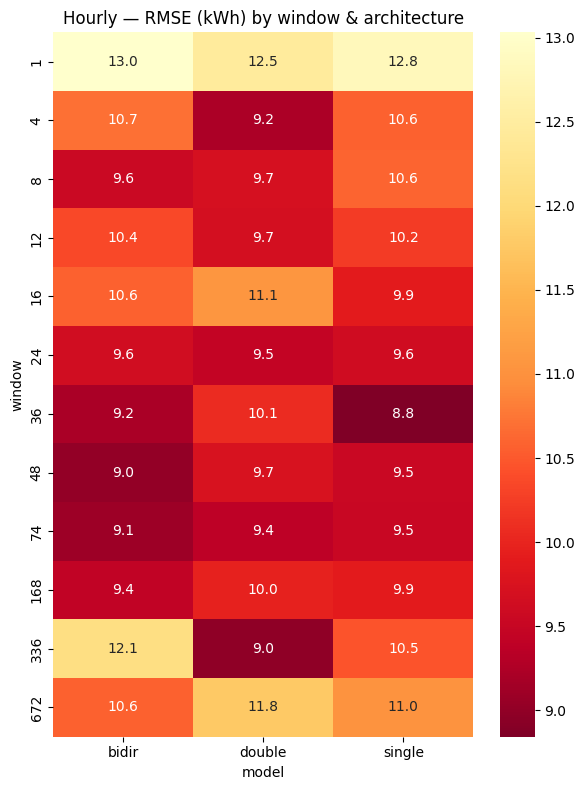

In [28]:
pivot = metrics_df.pivot(index="window", columns="model", values="rmse_kwh")
plt.figure(figsize=(6, 8))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd_r")
plt.title("Hourly — RMSE (kWh) by window & architecture")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "rmse_heatmap.png"), dpi=120)
plt.show()

## Done
